In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
try:
    df = pd.read_csv('/kaggle/input/house-prices-bangalore2025/house_prices_bangalore.csv')
except FileNotFoundError:
    df = pd.read_csv("house_prices_bangalore.csv")

In [3]:
df.head()

,area,location,bhk,bath,balcony,parking,furnishing,property_type,age,price
0,2065,Bannerghatta Road,2,3,0,1,Semi-Furnished,Independent House,3,17280000
1,1539,Yelahanka,3,1,0,1,Unfurnished,Villa,8,9410000
2,2048,Bannerghatta Road,3,1,2,0,Semi-Furnished,Independent House,10,20300000
3,1233,Sarjapur Road,3,2,1,2,Fully-Furnished,Apartment,12,9060000
4,2487,Yelahanka,3,3,2,1,Fully-Furnished,Villa,4,28660000


In [4]:
df.isnull().sum()

area             0
location         0
bhk              0
bath             0
balcony          0
parking          0
furnishing       0
property_type    0
age              0
price            0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   area           1000 non-null   int64 
 1   location       1000 non-null   object
 2   bhk            1000 non-null   int64 
 3   bath           1000 non-null   int64 
 4   balcony        1000 non-null   int64 
 5   parking        1000 non-null   int64 
 6   furnishing     1000 non-null   object
 7   property_type  1000 non-null   object
 8   age            1000 non-null   int64 
 9   price          1000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 78.3+ KB


In [6]:
df.duplicated().sum()

np.int64(0)

## EDA

In [7]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
area,1000.0,1.648511e+03,4.879092e+02,803.0,1226.75,1648.0,2075.25,2499.0
bhk,1000.0,3.082000e+00,1.364235e+00,1.0,2.00,3.0,4.00,5.0
bath,1000.0,2.557000e+00,1.415187e+00,1.0,1.00,2.0,3.00,6.0
balcony,1000.0,1.012000e+00,8.028079e-01,0.0,0.00,1.0,2.00,2.0
parking,1000.0,9.650000e-01,8.345487e-01,0.0,0.00,1.0,2.00,2.0
age,1000.0,8.040000e+00,4.338805e+00,1.0,4.00,8.0,12.00,15.0
price,1000.0,1.237301e+07,5.386504e+06,2850000.0,8405000.00,11320000.0,15430000.00,32730000.0


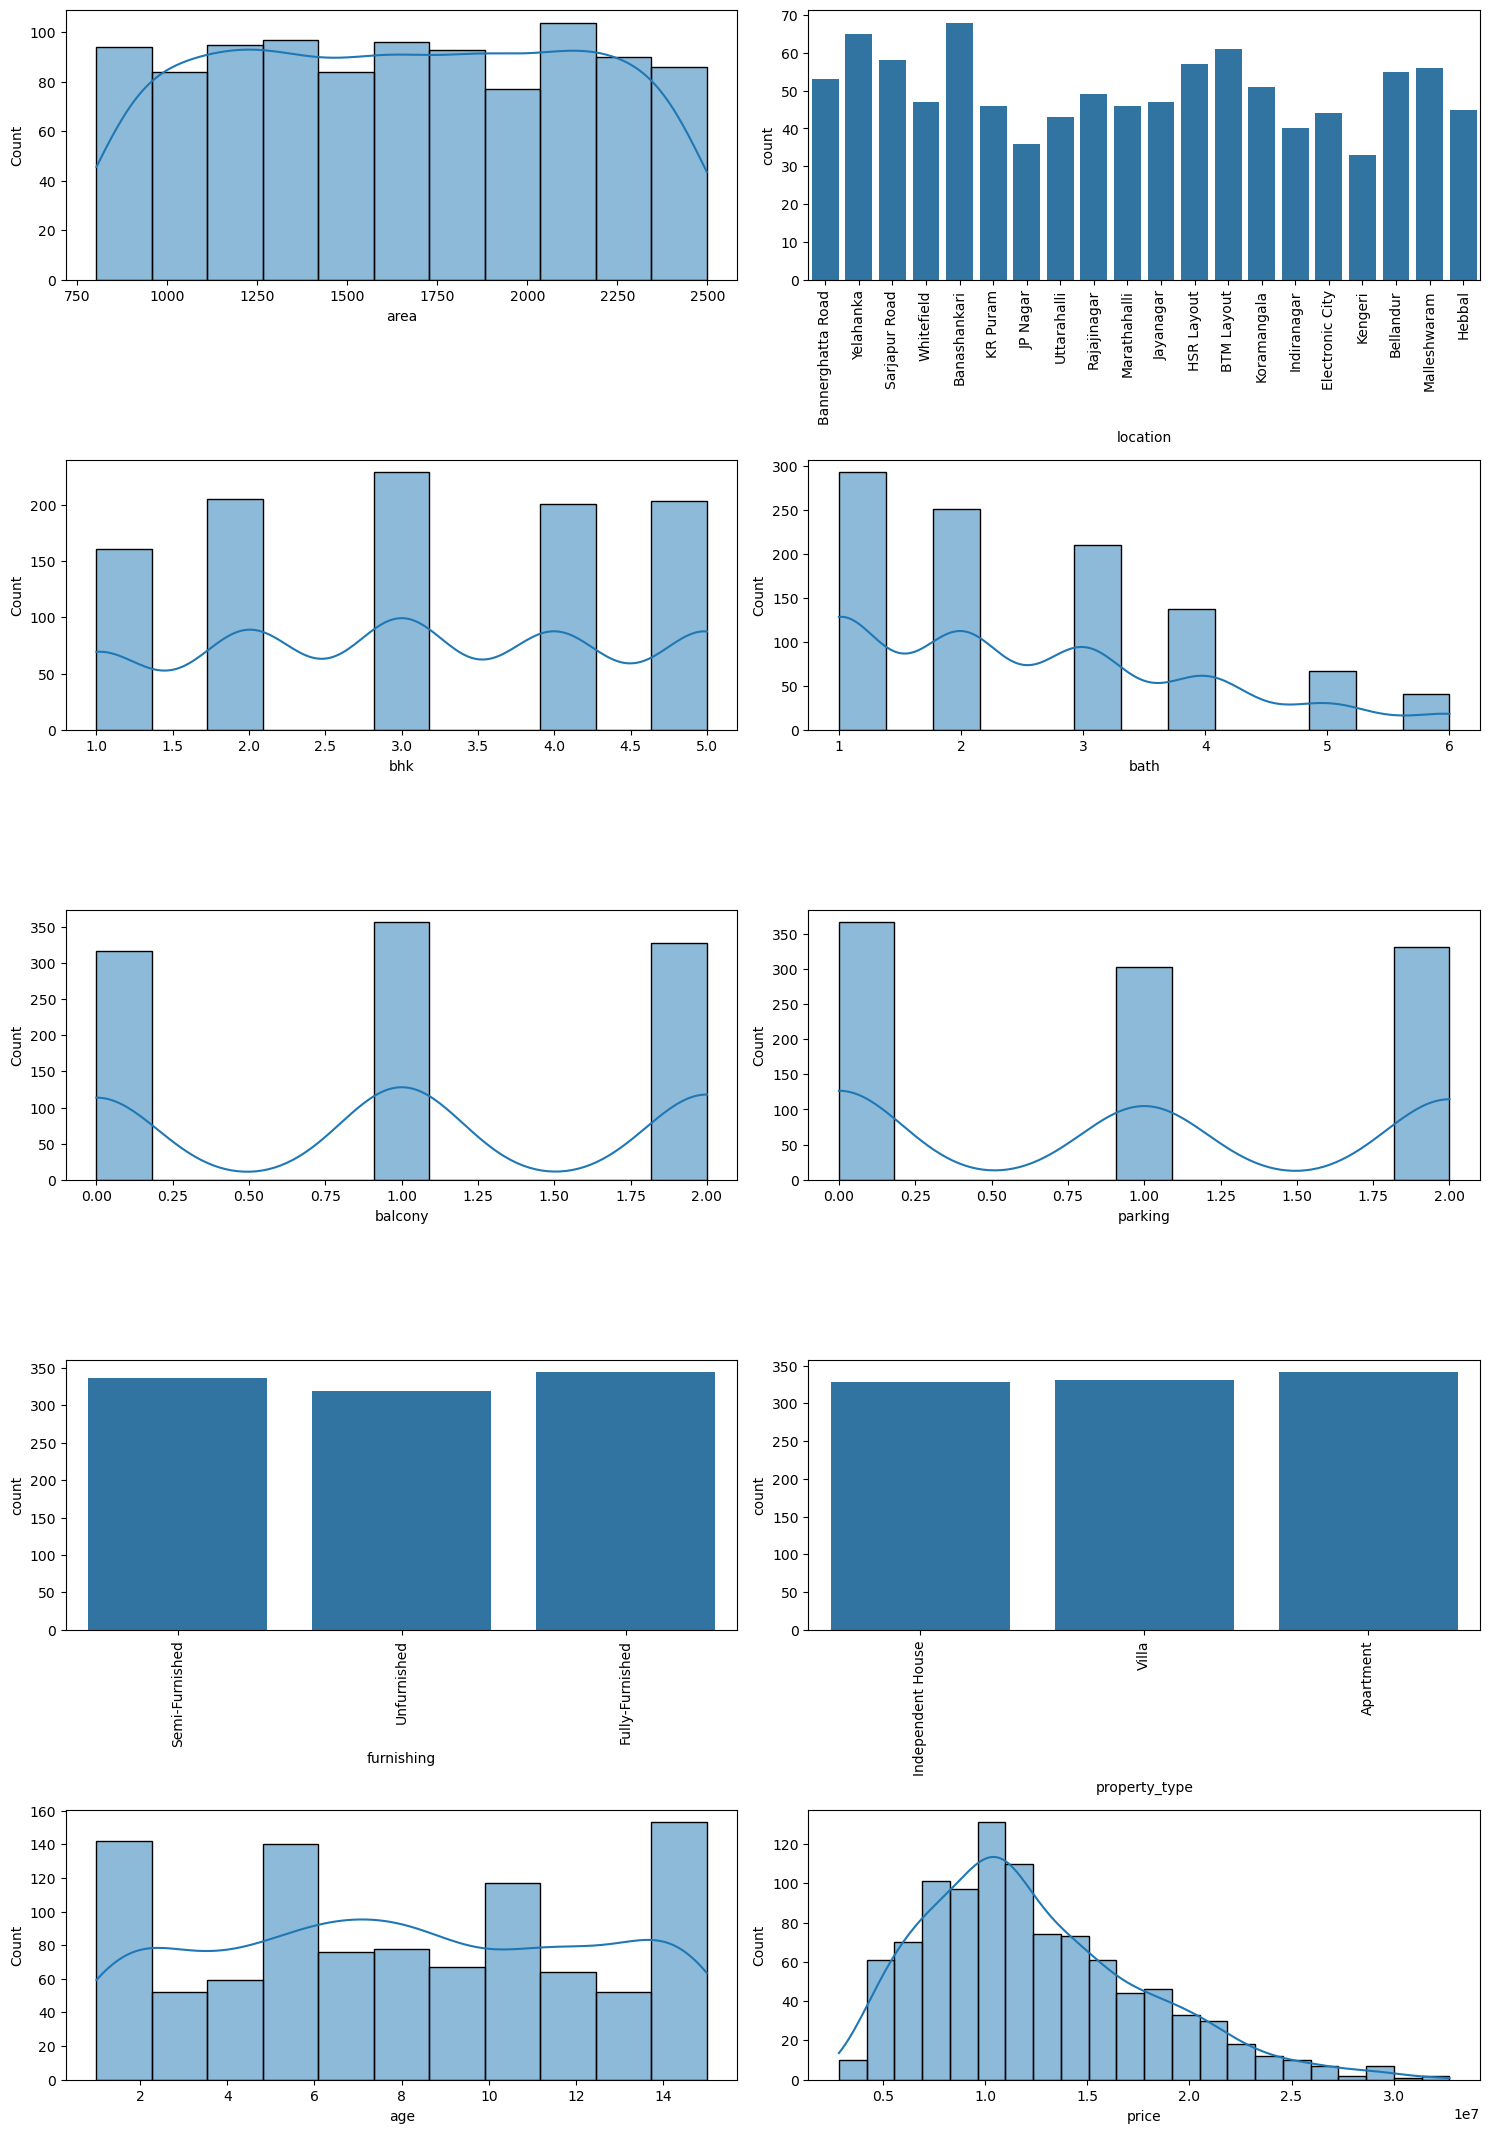

In [8]:
n = 1
plt.figure(figsize=(15, 30))
for i in df.columns:
    if n <= len(df.columns):
        if df[i].dtype == "int64":
            ax = plt.subplot(7, 2, n)
            sns.histplot(x= df[i], kde=True)
        else:
            ax = plt.subplot(7, 2, n)
            sns.countplot(x= df[i])
            plt.xticks(rotation = 90)
    n += 1
plt.tight_layout()
plt.show()

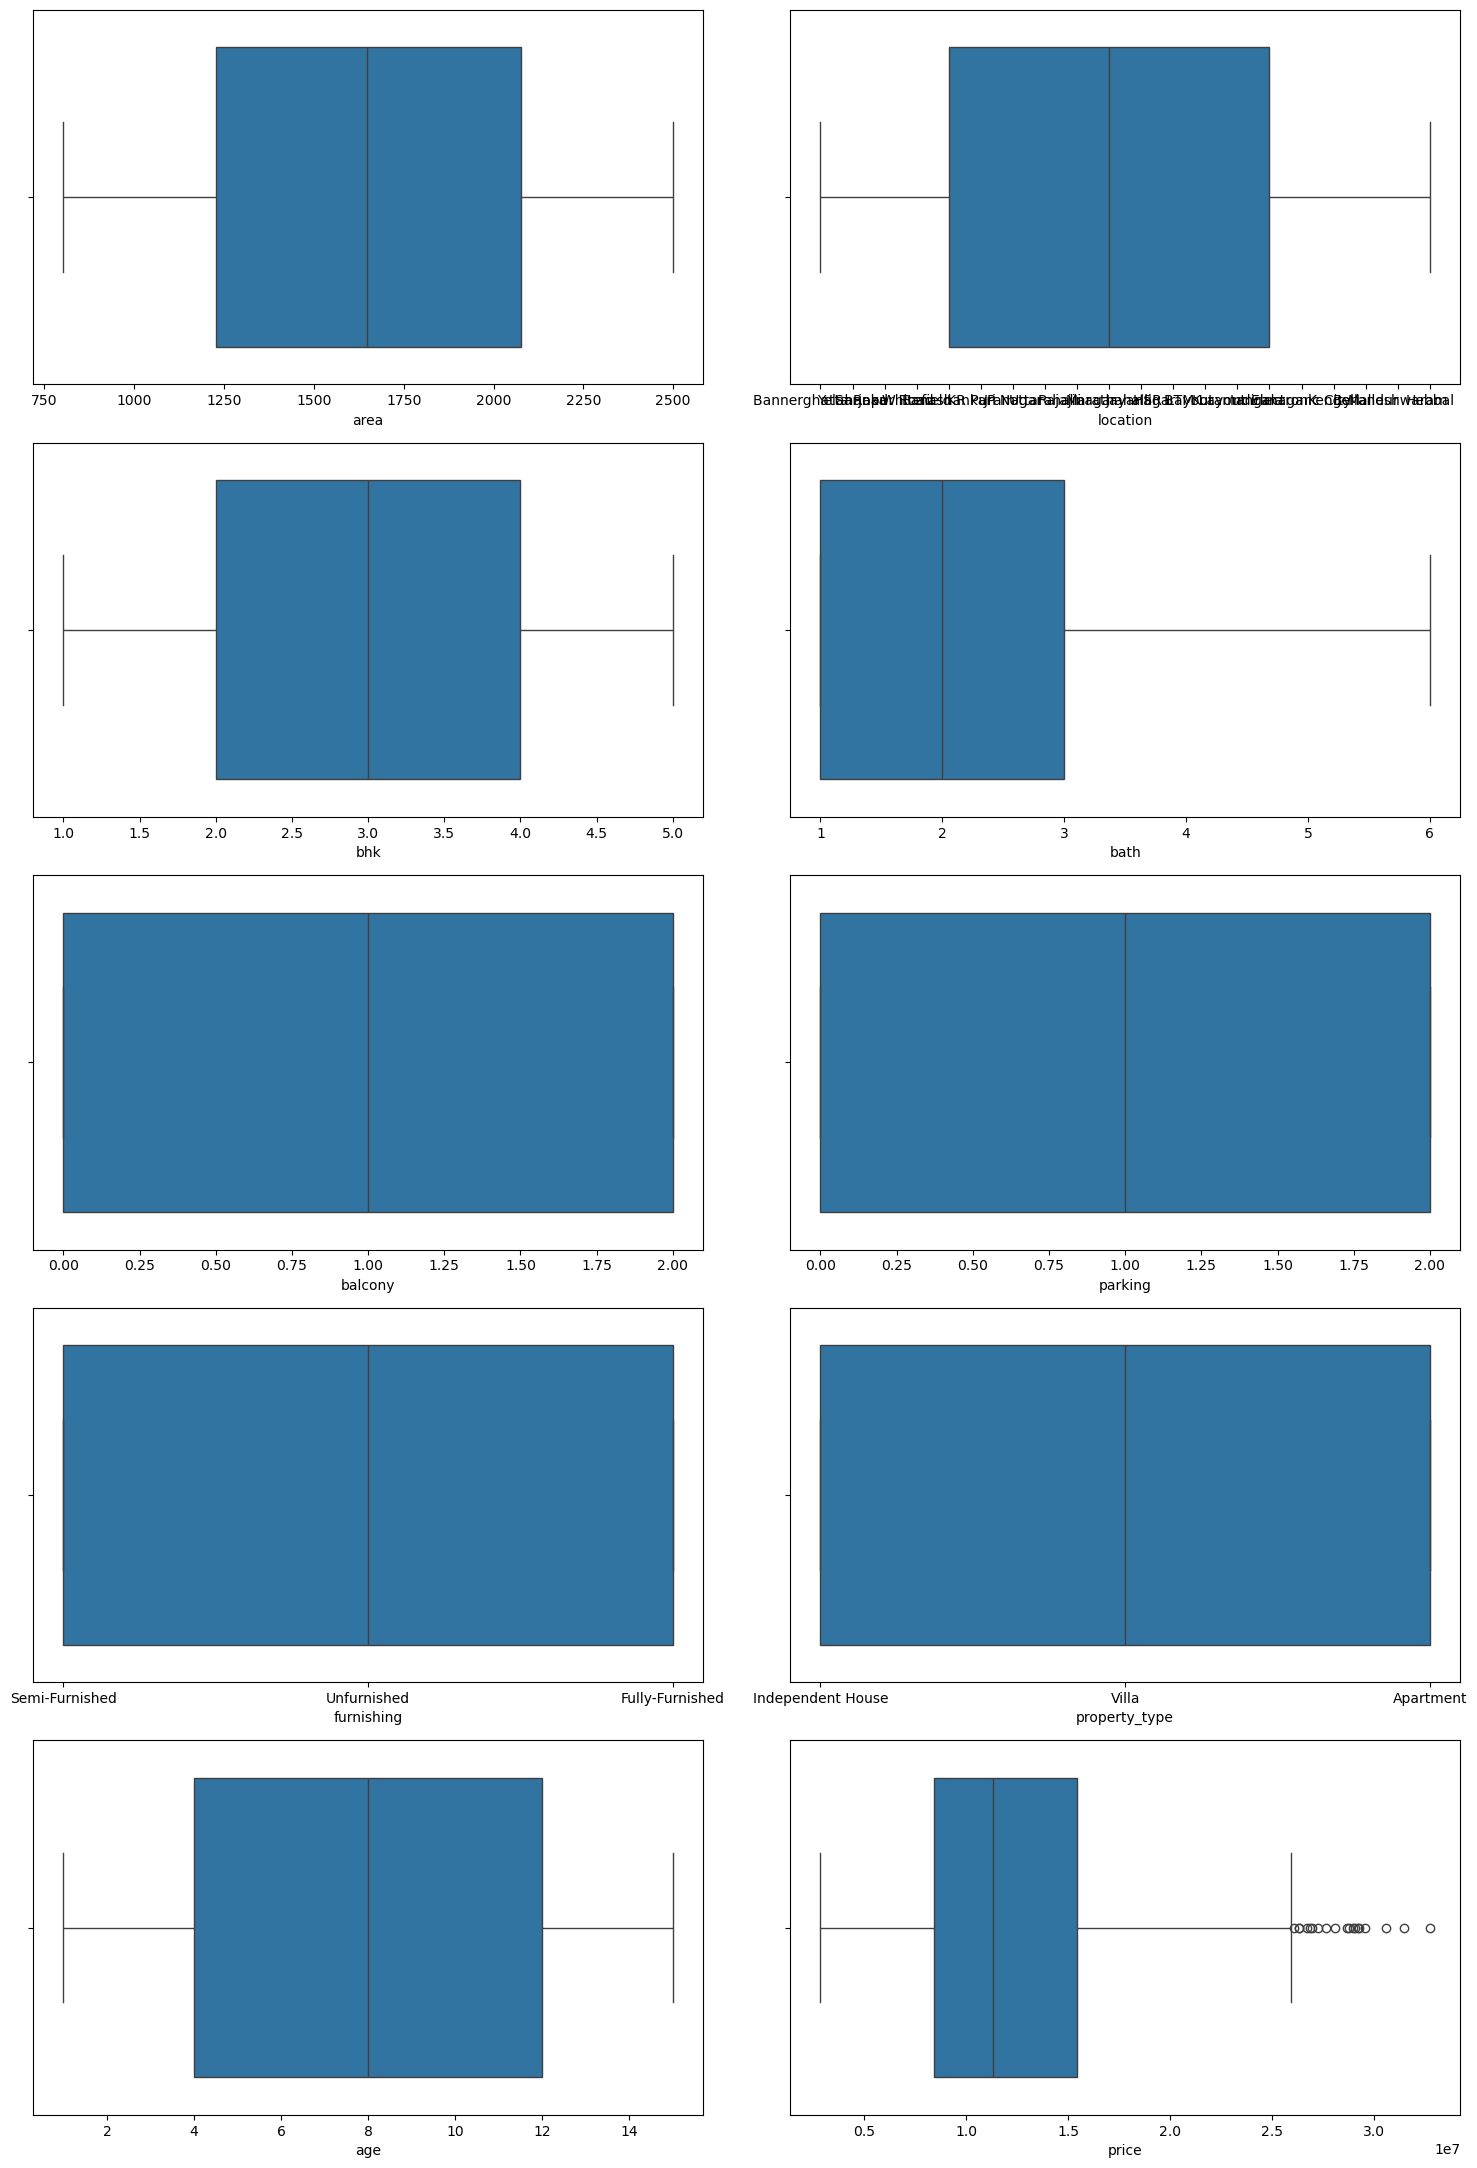

In [9]:
n = 1
plt.figure(figsize=(15, 30))
for i in df.columns:
    if n <= len(df.columns):
        ax = plt.subplot(7, 2, n)
        sns.boxplot(x= df[i])
    n += 1
plt.tight_layout()
plt.show()

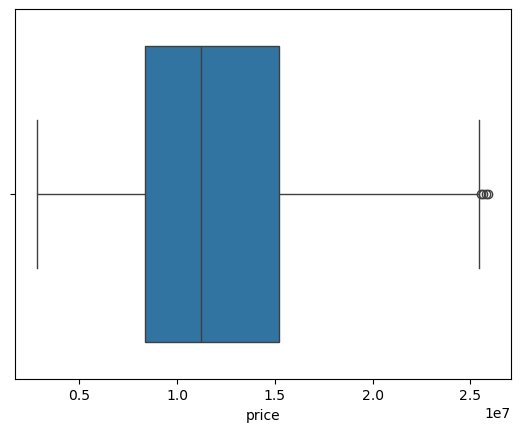

In [10]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 -q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

df = df[(df['price'] >= lower) & (df['price'] <= upper)]


sns.boxplot(x=df['price'])
plt.show()

### Feature Engineering

In [13]:
# Categorical Encoding
print(df['location'].value_counts())
print(df['furnishing'].value_counts())
print(df['property_type'].value_counts())

location
2    596
1    154
3    132
4     99
Name: count, dtype: int64
furnishing
Semi-Furnished     335
Fully-Furnished    329
Unfurnished        317
Name: count, dtype: int64
property_type
Apartment            341
Independent House    326
Villa                314
Name: count, dtype: int64


In [14]:
# Encoding on location column
df.loc[df['location'] == 'Banashankari', 'location'] = 'south'
df.loc[df['location'] == 'Yelahanka', 'location'] = 'north'
df.loc[df['location'] == 'BTM Layout', 'location'] = 'south'
df.loc[df['location'] == 'Sarjapur Road', 'location'] = 'south'
df.loc[df['location'] == 'HSR Layout', 'location'] = 'south'
df.loc[df['location'] == 'Malleshwaram', 'location'] = 'west'
df.loc[df['location'] == 'Bellandur', 'location'] = 'south'
df.loc[df['location'] == 'Bannerghatta Road', 'location'] = 'south'
df.loc[df['location'] == 'Koramangala', 'location'] = 'south'
df.loc[df['location'] == 'Rajajinagar', 'location'] = 'west'
df.loc[df['location'] == 'Whitefield', 'location'] = 'east'
df.loc[df['location'] == 'Jayanagar', 'location'] = 'south'
df.loc[df['location'] == 'Marathahalli', 'location'] = 'east'
df.loc[df['location'] == 'KR Puram', 'location'] = 'north'
df.loc[df['location'] == 'Hebbal', 'location'] = 'north'
df.loc[df['location'] == 'Electronic City', 'location'] = 'south'
df.loc[df['location'] == 'Uttarahalli', 'location'] = 'south'
df.loc[df['location'] == 'Indiranagar', 'location'] = 'east'
df.loc[df['location'] == 'JP Nagar', 'location'] = 'south'
df.loc[df['location'] == 'Kengeri', 'location'] = 'south'

# one hot encoding North south east west
df.loc[df['location'] == 'north', 'location'] = 1
df.loc[df['location'] == 'south', 'location'] = 2
df.loc[df['location'] == 'east', 'location'] = 3
df.loc[df['location'] == 'west', 'location'] = 4
df.loc[df['location'] == 'central', 'location'] = 5

df['location'] = df['location'].astype(int)
df['location'].value_counts()

C:\Users\nisha\AppData\Local\Temp\ipykernel_7948\88936966.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'south' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['location'] == 'Banashankari', 'location'] = 'south'


location
2    596
1    154
3    132
4     99
Name: count, dtype: int64

In [19]:
# One hot encoding on furnishing column
df.loc[df['furnishing'] == 'Fully-Furnished', 'furnishing'] = 3
df.loc[df['furnishing'] == 'Semi-Furnished', 'furnishing'] = 2
df.loc[df['furnishing'] == 'Unfurnished', 'furnishing'] = 1
df['furnishing'] = df['furnishing'].astype(int)
df['furnishing'].value_counts()

furnishing
2    335
3    329
1    317
Name: count, dtype: int64

In [20]:
df.loc[df['property_type'] == 'Apartment', 'property_type'] = 1
df.loc[df['property_type'] == 'Villa', 'property_type'] = 2
df.loc[df['property_type'] == 'Independent House', 'property_type'] = 3
df['property_type'] = df['property_type'].astype(int)
df['property_type'].value_counts()

property_type
1    341
3    326
2    314
Name: count, dtype: int64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   area           981 non-null    int64
 1   location       981 non-null    int64
 2   bhk            981 non-null    int64
 3   bath           981 non-null    int64
 4   balcony        981 non-null    int64
 5   parking        981 non-null    int64
 6   furnishing     981 non-null    int64
 7   property_type  981 non-null    int64
 8   age            981 non-null    int64
 9   price          981 non-null    int64
dtypes: int64(10)
memory usage: 84.3 KB


In [22]:
df.corr()

,area,location,bhk,bath,balcony,parking,furnishing,property_type,age,price
area,1.000000,0.037776,-0.001695,0.039493,-0.004686,-0.064416,-0.077435,0.077871,-0.010949,0.686581
location,0.037776,1.000000,-0.000323,-0.000620,0.002047,0.026078,-0.017208,-0.003506,0.007335,0.057377
bhk,-0.001695,-0.000323,1.000000,0.529470,0.013747,0.054847,-0.013750,-0.009736,0.012095,0.025299
bath,0.039493,-0.000620,0.529470,1.000000,0.050165,0.039260,-0.020944,0.013316,-0.001173,0.038568
balcony,-0.004686,0.002047,0.013747,0.050165,1.000000,0.043424,0.042081,0.006532,0.000105,0.034755
parking,-0.064416,0.026078,0.054847,0.039260,0.043424,1.000000,0.030664,0.017101,-0.050514,-0.023941
furnishing,-0.077435,-0.017208,-0.013750,-0.020944,0.042081,0.030664,1.000000,-0.036293,0.038586,0.131958
property_type,0.077871,-0.003506,-0.009736,0.013316,0.006532,0.017101,-0.036293,1.000000,0.019244,0.158188
age,-0.010949,0.007335,0.012095,-0.001173,0.000105,-0.050514,0.038586,0.019244,1.000000,-0.005123
price,0.686581,0.057377,0.025299,0.038568,0.034755,-0.023941,0.131958,0.158188,-0.005123,1.000000


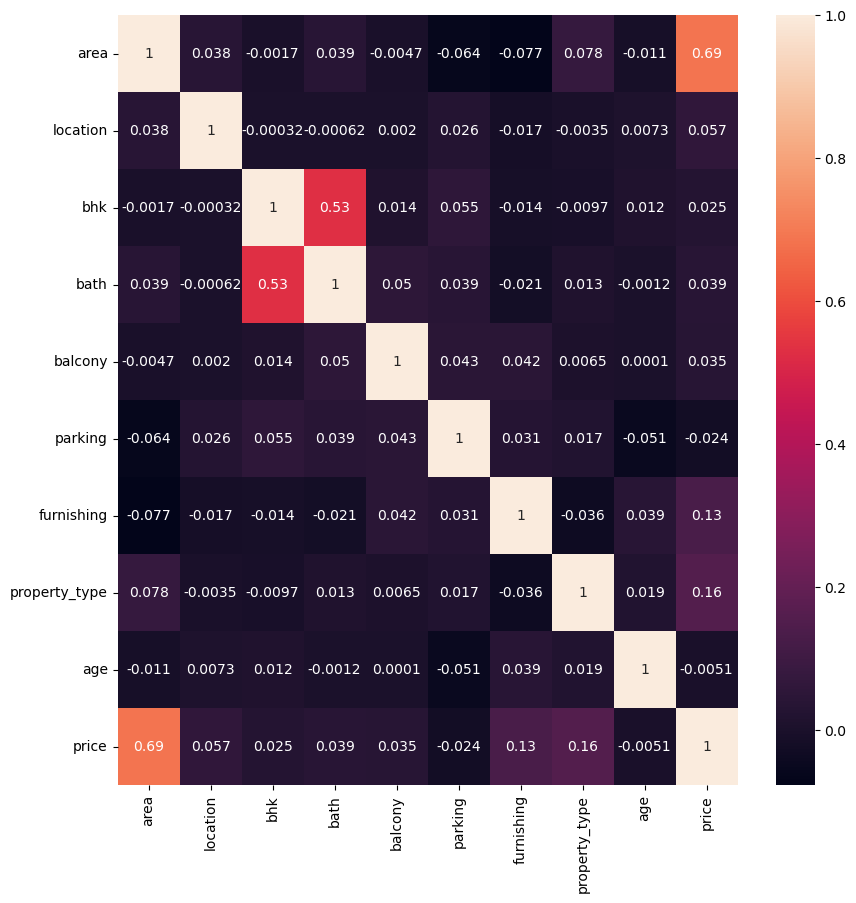

In [23]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(), annot=True)
plt.show()

### Model Creation

In [94]:
# defining x and y
x = df.drop(columns='price')
y = np.log1p(df['price'])
x.shape

(981, 9)

In [54]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

In [101]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=400,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.9,
    random_state=42)
gbr.fit(x_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=2, n_estimators=400,
                          random_state=42, subsample=0.9)

In [102]:
y_pred1 = grid.predict(x_test)

In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred1))
print("MSE:", mean_squared_error(y_test, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred1)))
print("R2 Score:", r2_score(y_test, y_pred1))

MAE: 0.2322438303133061
MSE: 0.07645236060838513
RMSE: 0.2765002000150906
R2 Score: 0.5748382366067047


In [104]:
# XGBoost Model
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42)
xgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [105]:
y_pred2 = xgb.predict(x_test)

In [106]:

print("MAE:", mean_absolute_error(y_test, y_pred2))
print("MSE:", mean_squared_error(y_test, y_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred2)))
print("R2 Score:", r2_score(y_test, y_pred2))

MAE: 0.23692666592382786
MSE: 0.08434410497659474
RMSE: 0.2904205656915411
R2 Score: 0.5309511947268089
